In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


## Imported all the necessary modules

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from scipy.sparse import hstack

## Loaded the datasets

In [3]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_sub = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

## Shape of the datasets and the first 5 columns of train dataset.

In [4]:
print(train.shape)
print(test.shape)
train.head(100)

(198000, 15)
(102000, 14)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2023-11-05 10:37:19.352819+00:00,39,0,0,0,1,0,4,10,none,none,none,False,Troll,2
96,2023-09-15 11:14:03.369825+00:00,72,0,0,0,0,1,0,5,NaN,NaN,NaN,False,"In the rural area where I live, I'd be happy j...",0
97,2024-03-03 00:38:02.507409+00:00,73,0,0,0,6,3,0,4,NaN,NaN,NaN,False,About time the United States begin to review a...,0
98,2024-03-23 21:04:57.883044+00:00,120,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Fascism, Communism and Socialism are all diffe...",2


In [5]:
count = train["comment"].str.contains("@ ", na=False).sum()
print("Number of comments with @:", count)

Number of comments with @: 183


In [6]:
train[train["comment"].str.contains("@", na=False)].head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
681,2023-08-07 20:12:34.971787+00:00,72,0,0,0,6,0,0,4,NaN,NaN,NaN,False,School ends at 3pm on Friday. Go to the mosque...,0
1003,2024-01-27 08:42:58.117307+00:00,120,0,0,1,1,0,0,4,NaN,NaN,NaN,False,"The bvq story above is quite clear, though it'...",2
1062,2022-12-26 03:37:29.237303+00:00,24,0,0,0,2,0,0,4,NaN,NaN,NaN,False,"""The only thing that creates cheaper housing a...",0
1079,2024-02-24 19:20:30.801296+00:00,120,0,1,0,2,0,4,10,black,none,female,False,"Exactly right, @alesia Ten or 15 years from n...",1
1952,2023-09-14 20:12:04.132342+00:00,72,0,3,2,0,2,0,4,NaN,NaN,NaN,False,six headed babies all in the name of science\n...,0



**The dataset contains user comments along with metadata such as emoticons,upvotes/downvotes,and timestamps. The goal is to predict the final category label assigned to each comment.**


In [7]:
train.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [9]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


### Descriptive Statistics Insights

1. **Post ID**
   - Values range from **20 to 129**.
   - Mean is around **68.45**.
   - This appears to be an **identifier column**, so it may not be useful for model prediction.

2. **Emoticon Features (`emoticon_1`, `emoticon_2`, `emoticon_3`)**
   - The **median is 0** for all emoticon columns.
   - This indicates that **most comments do not contain emoticons**.
   - A few rows have higher values (max values: 47, 11, 17), showing **some outliers**.

3. **Upvote Feature**
   - Average upvotes ≈ **2.6**.
   - Median is **1**, meaning most comments receive very few upvotes.
   - Maximum is **201**, showing **some highly popular comments**.

4. **Downvote Feature**
   - Average downvotes ≈ **0.66**.
   - Median is **0**, meaning most comments receive **no downvotes**.
   - Maximum value is **107**, indicating some extreme cases.

5. **`if_1` Feature**
   - Median is **0**, meaning most values are **zero**.
   - Maximum value is **1860**, which suggests **large outliers** in this feature.

6. **`if_2` Feature**
   - Values range from **3 to 1833**.
   - Mean ≈ **7.95** and median **6**, indicating moderate spread with some outliers.

7. **Target Variable (`label`)**
   - Values range from **0 to 3**, meaning this is a **multiclass classification problem with 4 classes**.
   - Median is **0**, suggesting **class 0 might be the most frequent class**.

## Visualization

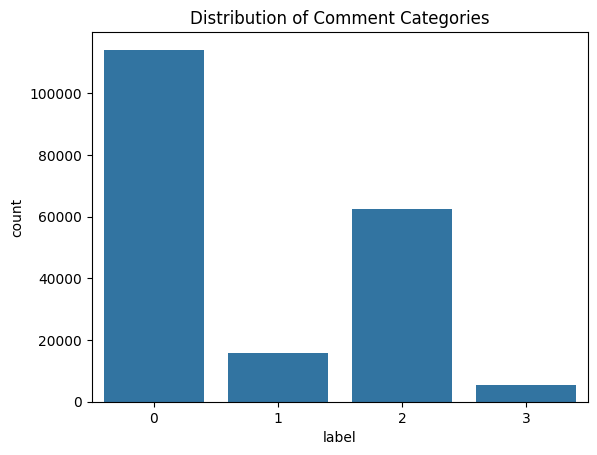

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="label", data=train)
plt.title("Distribution of Comment Categories")
plt.show()

- The target variable `label` has **4 classes**, with **class 0 being the most frequent** followed by class 2.  
- Classes **1 and 3 have much fewer samples**, indicating a **class imbalance** in the dataset.

**This model is imbalanced, with some categories appearing more frequently. This will affect model training and we will have to use class weights.** 

Text(0.5, 1.0, 'Comment Length Distribution')

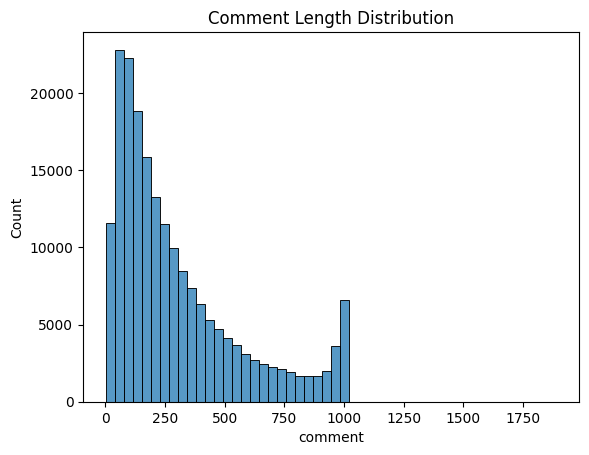

In [11]:
sns.histplot(train["comment"].str.len(),bins=50)
plt.title("Comment Length Distribution")

- Most comments are **short to medium length**, with the highest frequency around **100–300 characters**.  
- The distribution is **right-skewed**, meaning a few comments are very long but most are relatively short.

<Axes: xlabel='label', ylabel='upvote'>

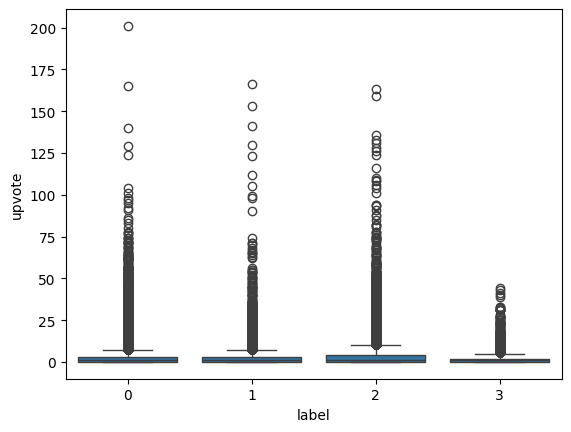

In [12]:
sns.boxplot(x="label", y="upvote", data=train)

- Most comments across all labels receive **very few upvotes**.  
- There are **many extreme outliers**, indicating some comments get very high upvotes regardless of category.

<Axes: xlabel='label', ylabel='downvote'>

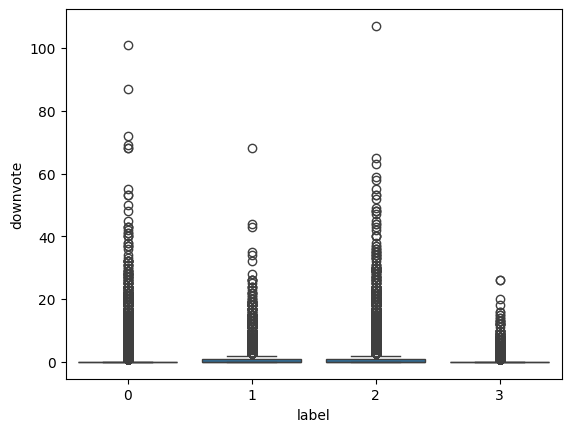

In [13]:
sns.boxplot(x="label", y="downvote", data=train)

<Axes: >

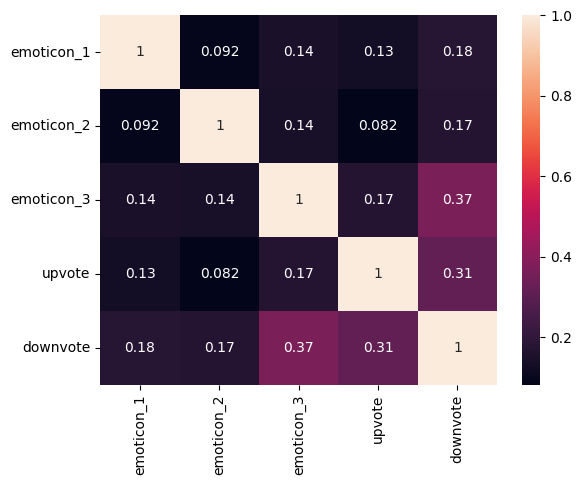

In [14]:
corr = train[["emoticon_1","emoticon_2","emoticon_3","upvote","downvote"]].corr()
sns.heatmap(corr, annot=True)

- Most features show **weak correlations**, indicating they provide largely independent information.  
- The highest correlations are between **emoticon_3 and downvote (~0.37)** and **upvote and downvote (~0.31)**, suggesting slightly related user interaction behavior.

In [15]:
df = train.copy()

# Preprocessing

### Missing values

In [16]:
train.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

### Handle Missing Comment

In [17]:
df = df.dropna(subset=["comment"])

**The comment column contains missing values which are removed since the text
content is essential for modeling.**

### Convert created_date

In [18]:
df["created_date"] = pd.to_datetime(df["created_date"])

df["year"] = df["created_date"].dt.year
df["month"] = df["created_date"].dt.month
df["day"] = df["created_date"].dt.day
df["hour"] = df["created_date"].dt.hour
df["day_of_week"] = df["created_date"].dt.dayofweek

### Handle Identity Columns


In [19]:
identity_cols = ["race", "religion", "gender"]

for col in identity_cols:
    df[col] = df[col].notnull().astype(int)

df["disability"] = df["disability"].astype(int)

### Dropping Unnecessary Columns

In [20]:
df = df.drop(columns=["created_date"])

df.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,year,month,day,hour,day_of_week
0,73,0,0,0,0,1,0,10,0,0,0,0,She might be a bright spot for a party keou on...,2,2024,1,18,8,3
1,39,0,0,0,6,0,0,4,0,0,0,0,"Under Alaska law, a non-tribal member is not b...",0,2024,3,24,21,6
2,31,0,1,1,0,0,0,10,0,0,0,0,in the future please spare me your strawman dr...,2,2024,4,24,20,2
3,39,0,0,0,5,0,0,10,0,0,0,0,"PS: That should have been ""rot"" instead of ""co...",2,2023,5,28,22,6
4,39,0,0,0,0,0,0,10,0,0,0,0,"Today, the confederate flag...tomorrow, the na...",2,2023,9,9,23,5


### Text cleaning.

In [21]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text) 
    text = re.sub(r"[^a-z0-9\s]", " ", text)  
    text = re.sub(r"\s+", " ", text).strip()
    return text
df["comment"] = df["comment"].apply(clean_text)

In [22]:
df["comment_length"] = df["comment"].apply(len)
df["word_count"] = df["comment"].apply(lambda x: len(x.split()))

## Feature Types

### Text Features
- comment

### Numerical Features
- emoticon_1, emoticon_2, emoticon_3
- upvote, downvote
- comment_length, word_count

### Categorical/Binary Features
- race
- religion
- gender
- disability
- if_1, if_2

### Datetime Features
- created_date (converted to year, month, hour, day_of_week)

In [23]:
text_column = "comment"

numeric_features =[
    "post_id",
    "emoticon_1",
    "emoticon_2",
    "emoticon_3",
    "upvote",
    "downvote",
    "if_1",
    "if_2",
    "race",
    "religion",
    "gender",
    "disability",
    "year",
    "month",
    "day",
    "hour",
    "day_of_week",
    "comment_length",
    "word_count"
]

target = "label"

## Train Test split

In [24]:
X = df[text_column]
y = df[target]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_num = df.loc[X_train_text.index, numeric_features]
X_test_num = df.loc[X_test_text.index, numeric_features]

# Feature Engineering

**TfidfVectorizer to process text comments**

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_tfidf = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1,3),
    min_df=3,
    max_df=0.9
)

X_train_word = word_tfidf.fit_transform(X_train_text)
X_test_word = word_tfidf.transform(X_test_text)


char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    max_features=30000,
    min_df=3
)

X_train_char = char_tfidf.fit_transform(X_train_text)
X_test_char = char_tfidf.transform(X_test_text)

In [26]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

X_train_final = hstack([
    X_train_word,
    X_train_char,
    X_train_num_scaled
])

X_test_final = hstack([
    X_test_word,
    X_test_char,
    X_test_num_scaled
])


***Standardization is applied to numerical features to ensure they
contribute equally to the model and prevent scale dominance.***

In [27]:
from scipy.sparse import csr_matrix

X_train_final = csr_matrix(X_train_final)
X_test_final = csr_matrix(X_test_final)


***A manual pipeline approach was used because the model combines sparse TF-IDF features with dense numerical features.***


## Model 1 Logistic regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_final, y_train)

pred_lr = lr.predict(X_test_final)

f1_lr = f1_score(y_test, pred_lr, average="macro")

print("LR F1:", f1_lr)

LR F1: 0.7979273944405035


## Model 2 SGD Classifier

In [29]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score, classification_report

sgd = SGDClassifier(loss="log_loss")
sgd.fit(X_train_final, y_train)

pred_sgd = sgd.predict(X_test_final)

f1_sgd = f1_score(y_test, pred_sgd, average="macro")

print("SGD F1:", f1_sgd)

SGD F1: 0.6880694764649454


## Model 3 LGBM Classifier

In [30]:
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, classification_report

model = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    learning_rate=0.1,
    n_estimators=400,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight={0:1, 1:2, 2:1.5, 3:5},
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

f1_lgb = f1_score(y_test, y_pred, average="macro")

print("LGBM F1:", f1_lgb)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 150.068481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6975491
[LightGBM] [Info] Number of data points in the train set: 158399, number of used features: 70016
[LightGBM] [Info] Start training from score -0.849580
[LightGBM] [Info] Start training from score -2.126724
[LightGBM] [Info] Start training from score -1.047620
[LightGBM] [Info] Start training from score -2.278803


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM F1: 0.8308704941730306

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22834
           1       0.77      0.81      0.79      3184
           2       0.87      0.92      0.89     12488
           3       0.70      0.66      0.68      1094

    accuracy                           0.92     39600
   macro avg       0.83      0.83      0.83     39600
weighted avg       0.92      0.92      0.92     39600



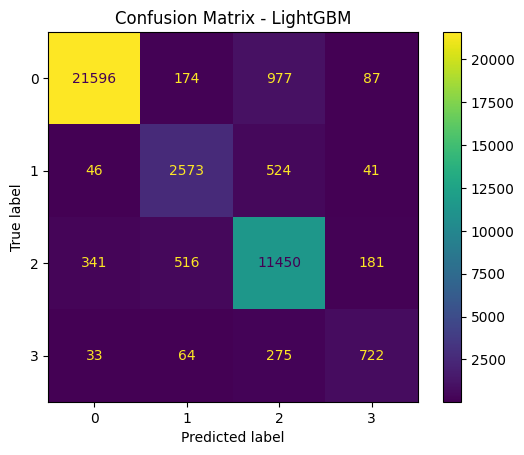

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - LightGBM")
plt.show()

In [32]:
results = pd.DataFrame({
"Model":["Logistic Regression","SGD","LightGBM"],
"Macro F1":[f1_lr, f1_sgd, f1_lgb]
})

results

,Model,Macro F1
0,Logistic Regression,0.797927
1,SGD,0.688069
2,LightGBM,0.830870


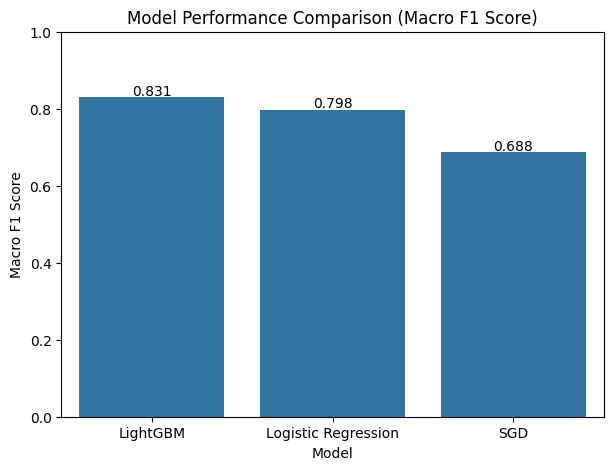

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.DataFrame({
    "Model": ["Logistic Regression", "SGD", "LightGBM"],
    "Macro F1": [f1_lr, f1_sgd, f1_lgb]
})

results = results.sort_values(by="Macro F1", ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(data=results, x="Model", y="Macro F1")

plt.title("Model Performance Comparison (Macro F1 Score)")
plt.xlabel("Model")
plt.ylabel("Macro F1 Score")

for i, v in enumerate(results["Macro F1"]):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.ylim(0, 1)
plt.show()

### Hyperparameter Tuning of LGBM Classifier

In [34]:
from sklearn.model_selection import train_test_split

X_small, _, y_small, _ = train_test_split(
    X_train_final,
    y_train,
    train_size=0.3,
    stratify=y_train,
    random_state=42
)
print("Subset shape:", X_small.shape)

Subset shape: (47519, 70019)


In [35]:
X_s_tr, X_s_val, y_s_tr, y_s_val = train_test_split(
    X_small,
    y_small,
    test_size=0.2,
    stratify=y_small,
    random_state=42
)

In [36]:
from itertools import product
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

learning_rates = [0.03, 0.05]
num_leaves_list = [31, 64]
best_score = 0
best_params = {}

for lr, nl in product(learning_rates, num_leaves_list):
    print(f"\nTraining with learning rate={lr}, num leaves={nl}")
    
    model = LGBMClassifier(
        objective="multiclass",
        num_class=4,
        learning_rate=lr,
        num_leaves=nl,
        n_estimators=400,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_s_tr, y_s_tr)
    
    y_val_pred = model.predict(X_s_val)
    
    score = f1_score(y_s_val, y_val_pred, average="macro")
    print(f"Validation Macro F1: {score}")
    
    if score > best_score:
        best_score = score
        best_params = {
            "learning_rate": lr,
            "num_leaves": nl
        }

print("\nBest Score:", best_score)
print("Best Params:", best_params)


Training with learning rate=0.03, num leaves=31
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 21.246471 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3058913
[LightGBM] [Info] Number of data points in the train set: 38015, number of used features: 48138
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation Macro F1: 0.8099495550684365

Training with learning rate=0.03, num leaves=64
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 15.245269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3058913
[LightGBM] [Info] Number of data points in the train set: 38015, number of used features: 48138
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation Macro F1: 0.8142003139454065

Training with learning rate=0.05, num leaves=31
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 24.271836 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3058913
[LightGBM] [Info] Number of data points in the train set: 38015, number of used features: 48138
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation Macro F1: 0.8099727233828931

Training with learning rate=0.05, num leaves=64
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 21.293952 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3058913
[LightGBM] [Info] Number of data points in the train set: 38015, number of used features: 48138
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation Macro F1: 0.814504721864272

Best Score: 0.814504721864272
Best Params: {'learning_rate': 0.05, 'num_leaves': 64}


## Preprocessing of Test Dataset

In [37]:
test["comment"] = test["comment"].apply(clean_text)

test["created_date"] = pd.to_datetime(test["created_date"])
test["year"] = test["created_date"].dt.year
test["month"] = test["created_date"].dt.month
test["day"] = test["created_date"].dt.day
test["hour"] = test["created_date"].dt.hour
test["day_of_week"] = test["created_date"].dt.dayofweek

for col in ["race", "religion", "gender"]:
    test[col] = test[col].notnull().astype(int)

test["disability"] = test["disability"].astype(int)

test["comment_length"] = test["comment"].apply(len)
test["word_count"] = test["comment"].apply(lambda x: len(x.split()))


In [38]:
word_tfidf = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1,3),
    min_df=3,
    max_df=0.9
)

X_full_word = word_tfidf.fit_transform(df["comment"])
X_test_word = word_tfidf.transform(test["comment"])


char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    max_features=30000,
    min_df=3
)

X_full_char = char_tfidf.fit_transform(df["comment"])
X_test_char = char_tfidf.transform(test["comment"])


In [39]:
numeric_features = [
    "post_id","emoticon_1","emoticon_2","emoticon_3",
    "upvote","downvote","if_1","if_2",
    "race","religion","gender","disability",
    "year","month","day","hour","day_of_week",
    "comment_length","word_count"
]

scaler = StandardScaler()

X_full_num = scaler.fit_transform(df[numeric_features])
X_test_num = scaler.transform(test[numeric_features])

In [40]:
from scipy.sparse import hstack

X_full_final = hstack([
    X_full_word,
    X_full_char,
    X_full_num
]).tocsr()

X_test_final = hstack([
    X_test_word,
    X_test_char,
    X_test_num
]).tocsr()


### Training final model

In [41]:
from lightgbm import LGBMClassifier

final_model = LGBMClassifier(
    objective="multiclass",
    num_class=4,
    learning_rate=0.05,
    n_estimators=800,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_full_final, df["label"])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 190.017318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7760176
[LightGBM] [Info] Number of data points in the train set: 197999, number of used features: 70019
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, n_estimators=800, n_jobs=-1, num_class=4,
               num_leaves=64, objective='multiclass', random_state=42,
               subsample=0.8)

In [42]:
test_preds = final_model.predict(X_test_final)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Creating Submission File

In [43]:
submission = pd.DataFrame({
    "ID": range(1, len(test_preds) + 1),
    "label": test_preds
})
submission.to_csv("submission.csv", index=False)

my_sub = pd.read_csv("/kaggle/working/submission.csv")
my_sub.shape